# 🔬 Bài Toán Người Du Lịch (TSP) — Giải bằng QAOA Lượng Tử

---

## Giới Thiệu

**Travelling Salesman Problem (TSP)** là bài toán tối ưu tổ hợp kinh điển:

> Cho $n$ thành phố và ma trận khoảng cách $W_{uv}$, tìm hành trình ngắn nhất đi qua mỗi thành phố đúng **một lần** rồi quay về điểm xuất phát.

TSP thuộc lớp **NP-Hard**: số hành trình cần kiểm tra là $(n-1)!/2$, tăng theo giai thừa.

### Giải Pháp: QAOA (Quantum Approximate Optimization Algorithm)

QAOA (Farhi et al., 2014) là thuật toán **lai lượng tử–cổ điển** tìm nghiệm xấp xỉ cho bài toán tối ưu tổ hợp.
Notebook này sử dụng trực tiếp code `tsp_qaoa.py`, `coefficient.py`, `hamiltonian.py`, `utilities.py` để so sánh **hai phương án mã hóa qubit**:

| Encoding | Số qubit | Mô tả |
|---|---|---|
| $n^2$ | $(n-1)^2$ | Biến nhị phân $x_{i,j}$: thành phố $i$ ở vị trí $j$ |
| $n\log n$ | $\lceil\log_2 n\rceil \cdot (n-1)$ | Biểu diễn nhị phân, tiết kiệm qubit |

---
**Cấu trúc notebook:**
1. Cài đặt & Import (thư viện + code của project)
2. Dữ liệu đầu vào & Trực quan hóa mạng lưới
3. Hamiltonian TSP (công thức toán học)
4. Tính hệ số bằng `coefficient.py`
5. Xây dựng Hamiltonian Pauli bằng `hamiltonian.py`
6. **Vẽ mạch QAOA bằng Qiskit** (`TSP_QAOA.create_qaoa_circ()`)
7. Tối ưu hóa với `TSP_QAOA.optimize_objective()`
8. Phân tích kết quả: AR, True Percentage, Rank
9. So sánh $n^2$ vs $n\log n$ trên nhiều mẫu
10. So sánh với thuật toán cổ điển

---
## 1. Cài Đặt & Import

In [1]:
# Cài đặt (bỏ comment nếu chưa cài)
# Yêu cầu: Qiskit >= 2.0  (không cần qiskit-aer)
# !pip install "qiskit>=2.0" sympy scipy matplotlib numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools
import math
import time
import pickle as pkl

# ── Qiskit (2.x) ────────────────────────────────────────────────────────────
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import transpile

# ── Code của project (đảm bảo các file .py nằm cùng thư mục notebook) ───────
from tsp_qaoa  import TSP_QAOA
from utilities import (euclidean_distance, path_distance,
                        check_validity, generate_binary_nums, path_rev)
import coefficient
import hamiltonian

plt.rcParams.update({
    'font.family'    : 'DejaVu Sans',
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'figure.facecolor': 'white',
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
})

import qiskit
print("✅ Import thành công!")
print(f"   Qiskit     : {qiskit.__version__}")
print(f"   NumPy      : {np.__version__}")
print("   Backend    : Qiskit built-in Statevector (no qiskit-aer needed)")

✅ Import thành công!
   Qiskit     : 2.3.0
   NumPy      : 2.2.6
   Backend    : Qiskit built-in Statevector (no qiskit-aer needed)


---
## 2. Dữ Liệu Đầu Vào & Trực Quan Hóa Mạng Lưới

In [3]:
# ── Tạo tọa độ ví dụ: 4 thành phố (nhỏ để quan sát mạch rõ ràng) ─────────
np.random.seed(42)

coordinates = np.array([
    [0.0, 0.0],   # Thành phố 0
    [2.0, 3.0],   # Thành phố 1
    [5.0, 1.0],   # Thành phố 2
    [3.5, 4.5],   # Thành phố 3
])
city_names = ["City 0", "City 1", "City 2", "City 3"]
n = coordinates.shape[0]

# Ma trận khoảng cách
W = np.array([[euclidean_distance(coordinates[i], coordinates[j])
               for j in range(n)] for i in range(n)])

print(f"Số thành phố: n = {n}")
print(f"n² encoding  : {(n-1)**2} qubit")
print(f"nlogn encoding: {int(np.ceil(np.log2(n)))*(n-1)} qubit  (k={int(np.ceil(np.log2(n)))})") 
print(f"Số hành trình cần duyệt: {math.factorial(n-1)//2}")
print()
print("Ma trận khoảng cách W:")
hdr = "        " + "   ".join(f"City{j}" for j in range(n))
print(hdr)
for i in range(n):
    row = f"City{i}  " + "   ".join(f"{W[i,j]:5.3f}" for j in range(n))
    print(row)

Số thành phố: n = 4
n² encoding  : 9 qubit
nlogn encoding: 6 qubit  (k=2)
Số hành trình cần duyệt: 3

Ma trận khoảng cách W:
        City0   City1   City2   City3
City0  0.000   3.606   5.099   5.701
City1  3.606   0.000   3.606   2.121
City2  5.099   3.606   0.000   3.808
City3  5.701   2.121   3.808   0.000


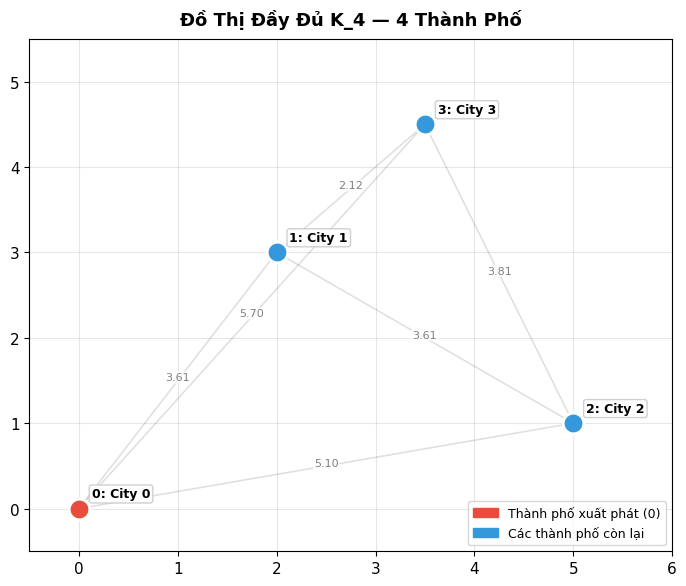

Tổng số cạnh trong K_4: 6


In [4]:
def plot_network(ax, coords, names, title, tour=None, color='royalblue'):
    """Vẽ đồ thị thành phố đầy đủ hoặc một hành trình cụ thể."""
    n_c = len(coords)
    W2  = np.array([[euclidean_distance(coords[i], coords[j])
                     for j in range(n_c)] for i in range(n_c)])

    if tour is None:
        for i in range(n_c):
            for j in range(i+1, n_c):
                ax.plot([coords[i,0], coords[j,0]], [coords[i,1], coords[j,1]],
                        'k-', alpha=0.12, lw=1.2)
                mx, my = (coords[i,0]+coords[j,0])/2, (coords[i,1]+coords[j,1])/2
                ax.text(mx, my, f'{W2[i,j]:.2f}', fontsize=8, ha='center', color='gray',
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='white',
                                  alpha=0.7, edgecolor='none'))
    else:
        for idx in range(len(tour)):
            i, j = tour[idx], tour[(idx+1) % len(tour)]
            ax.annotate("",
                xy=(coords[j,0], coords[j,1]),
                xytext=(coords[i,0], coords[i,1]),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2,
                                connectionstyle='arc3,rad=0.07'))
            mx, my = (coords[i,0]+coords[j,0])/2, (coords[i,1]+coords[j,1])/2
            ax.text(mx, my+0.1, f'{W2[i,j]:.2f}', fontsize=8.5, ha='center',
                    color=color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='lightyellow',
                              alpha=0.9, edgecolor=color, lw=0.7))

    node_colors = ['#e74c3c'] + ['#3498db'] * (n_c - 1)
    for i in range(n_c):
        ax.scatter(coords[i,0], coords[i,1], s=220, c=node_colors[i],
                   zorder=5, edgecolors='white', lw=2)
        ax.text(coords[i,0]+0.13, coords[i,1]+0.13,
                f'{i}: {names[i]}', fontsize=9, fontweight='bold', zorder=6,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.92, edgecolor='#ccc'))
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlim(-0.5, max(coords[:,0])+1.0)
    ax.set_ylim(-0.5, max(coords[:,1])+1.0)
    if tour:
        d = sum(W2[tour[i], tour[(i+1)%len(tour)]] for i in range(len(tour)))
        ax.set_xlabel(f'Tổng quãng đường: {d:.4f}', fontsize=10, color=color)


fig, ax = plt.subplots(figsize=(7, 6))
plot_network(ax, coordinates, city_names, f'Đồ Thị Đầy Đủ K_{n} — {n} Thành Phố')
ax.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Thành phố xuất phát (0)'),
    mpatches.Patch(color='#3498db', label='Các thành phố còn lại'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()
print(f"Tổng số cạnh trong K_{n}: {n*(n-1)//2}")

---
## 3. Công Thức Hamiltonian TSP

### 3.1 Mã Hóa $n^2$ (`coefficient.coeff_n2`)

Biến nhị phân $x_{i,j} \in \{0,1\}$: thành phố $i$ ở vị trí $j$.

$$H = \underbrace{A\left[\sum_{i}\left(1 - \sum_{j} x_{i,j}\right)^2 + \sum_{j}\left(1 - \sum_{i} x_{i,j}\right)^2\right]}_{H_A\ (\text{penalty})} + \underbrace{B\sum_{u,v} W_{uv}\sum_{i} x_{u,i}\, x_{v,i+1}}_{H_B\ (\text{chi phí})}$$

Với $A = 10 \times \max(W)$, $B = 1$.

### 3.2 Chuyển sang Ising

$$x = \frac{1-z}{2}, \quad z \in \{+1,-1\} \implies H_{\text{Ising}} = c_0 I + \sum_i c_i Z_i + \sum_{i<j} c_{ij} Z_i Z_j$$

### 3.3 Mã Hóa $n\log n$ (`coefficient.coeff_nlogn`)

Mỗi vị trí dùng $k = \lceil\log_2 n\rceil$ bit thay vì $n$ bit one-hot → tiết kiệm qubit.

### 3.4 Mạch QAOA

$$|\psi(\boldsymbol{\beta},\boldsymbol{\gamma})\rangle = \prod_{l=1}^{p} e^{-i\beta_l H_M}\, e^{-i\gamma_l H_P}\, |+\rangle^{\otimes n_q}$$

Bộ tối ưu cổ điển (**Basin-hopping**) tìm $\boldsymbol{\beta}^*, \boldsymbol{\gamma}^*$ để cực tiểu hóa $\langle H_P\rangle$.

---
## 4. Tính Hệ Số Hamiltonian — `coefficient.py`

In [5]:
# ── Gọi trực tiếp coefficient.coeff_n2() và coefficient.coeff_nlogn() ─────

print("=" * 55)
print("  Tính hệ số — Mã hóa n²")
print("=" * 55)
t0 = time.perf_counter()
coeff_n2 = coefficient.coeff_n2(coordinates)
t_n2 = time.perf_counter() - t0

print(f"Thời gian   : {t_n2:.2f}s")
print(f"Hằng số c0  : {float(coeff_n2[0][1]):.4f}")
print(f"Hệ số bậc 1 : {len(coeff_n2[1])} hạng")
print(f"Hệ số bậc 2 : {len(coeff_n2[2])} hạng")
print("\n5 hệ số bậc 1 đầu tiên:")
for item in coeff_n2[1][:5]:
    print(f"  Z_{item[0]} : {float(item[1]):+.4f}")

print()
print("=" * 55)
print("  Tính hệ số — Mã hóa nlogn")
print("=" * 55)
t0 = time.perf_counter()
coeff_nlogn = coefficient.coeff_nlogn(coordinates)
t_nlogn = time.perf_counter() - t0
k = int(np.ceil(np.log2(n)))

print(f"Thời gian   : {t_nlogn:.2f}s")
print(f"k           : {k}")
print(f"Cấu trúc    : [coeff0, coeff1, coeff2] — {[type(c).__name__ for c in coeff_nlogn]}")

print()
print("── So sánh ──")
print(f"  n²    : {(n-1)**2} qubit, {1+len(coeff_n2[1])+len(coeff_n2[2])} hạng Pauli")
print(f"  nlogn : {k*(n-1)} qubit, tiết kiệm {(n-1)**2 - k*(n-1)} qubit "
      f"({((n-1)**2-k*(n-1))/(n-1)**2*100:.0f}%)")

  Tính hệ số — Mã hóa n²
Thời gian   : 0.48s
Hằng số c0  : 365.9928
Hệ số bậc 1 : 9 hạng
Hệ số bậc 2 : 36 hạng

5 hệ số bậc 1 đầu tiên:
  Z_0 : -60.2433
  Z_1 : -61.4116
  Z_2 : -61.3415
  Z_3 : -59.8722
  Z_4 : -60.7155

  Tính hệ số — Mã hóa nlogn
Thời gian   : 0.03s
k           : 2
Cấu trúc    : [coeff0, coeff1, coeff2] — ['list', 'list', 'list']

── So sánh ──
  n²    : 9 qubit, 46 hạng Pauli
  nlogn : 6 qubit, tiết kiệm 3 qubit (33%)


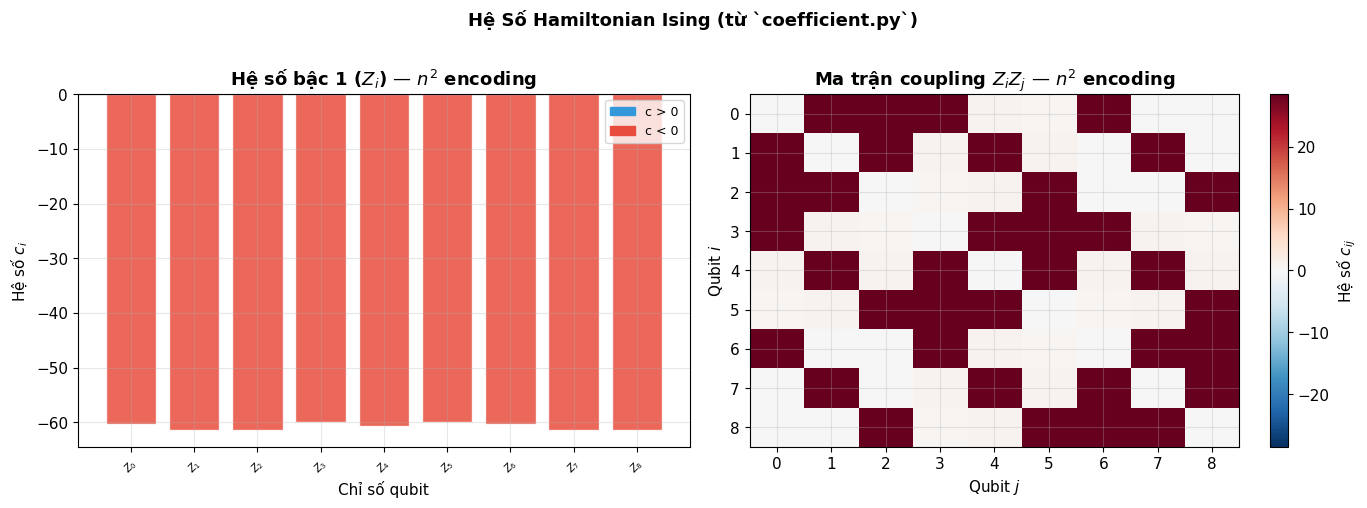

In [6]:
# ── Trực quan hóa hệ số Hamiltonian ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hệ số bậc 1 — barplot
ax = axes[0]
qubits1 = [item[0] for item in coeff_n2[1]]
coeffs1 = [float(item[1]) for item in coeff_n2[1]]
colors1 = ['#e74c3c' if c < 0 else '#3498db' for c in coeffs1]
ax.bar(range(len(coeffs1)), coeffs1, color=colors1, alpha=0.85, edgecolor='white')
ax.set_xlabel('Chỉ số qubit')
ax.set_ylabel('Hệ số $c_i$')
ax.set_title('Hệ số bậc 1 ($Z_i$) — $n^2$ encoding', fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(coeffs1)))
ax.set_xticklabels([f'$Z_{{{q}}}$' for q in qubits1], fontsize=7, rotation=45)
ax.legend(handles=[
    mpatches.Patch(color='#3498db', label='c > 0'),
    mpatches.Patch(color='#e74c3c', label='c < 0'),
], fontsize=9)

# Hệ số bậc 2 — heatmap ma trận coupling
ax = axes[1]
nq = (n-1)**2
mat = np.zeros((nq, nq))
for item in coeff_n2[2]:
    i, j, c = item[0], item[1], float(item[2])
    mat[i, j] = c
    mat[j, i] = c
vmax = np.abs(mat).max() or 1
im = ax.imshow(mat, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='Hệ số $c_{ij}$')
ax.set_title('Ma trận coupling $Z_iZ_j$ — $n^2$ encoding', fontweight='bold')
ax.set_xlabel('Qubit $j$'); ax.set_ylabel('Qubit $i$')

plt.suptitle('Hệ Số Hamiltonian Ising (từ `coefficient.py`)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Xây Dựng Hamiltonian Pauli — `hamiltonian.py`

In [7]:
# ── Gọi hamiltonian.hamiltonian_n2, hamiltonian_nlogn, mixer ──────────────
nqubit_n2    = (n-1)**2
nqubit_nlogn = k * (n-1)

Hp_n2    = hamiltonian.hamiltonian_n2(coeff_n2, nqubit_n2)
Hm_n2    = hamiltonian.mixer(nqubit_n2)

Hp_nlogn = hamiltonian.hamiltonian_nlogn(coeff_nlogn, nqubit_nlogn, n, k)
Hm_nlogn = hamiltonian.mixer(nqubit_nlogn)

print("── Problem Hamiltonian H_P ──────────────────────────────")
print(f"  n²    : {len(Hp_n2)} hạng Pauli ({nqubit_n2} qubit)")
print(f"  nlogn : {len(Hp_nlogn)} hạng Pauli ({nqubit_nlogn} qubit)")

print("\n  5 hạng đầu tiên H_P (n²):")
for p, c in zip(Hp_n2.paulis[:5], Hp_n2.coeffs[:5]):
    print(f"    {float(c.real):+8.4f} × {p.to_label()}")

print()
print("── Mixing Hamiltonian H_M = Σ X_i ───────────────────────")
print(f"  n²    : {len(Hm_n2)} hạng Pauli-X")
print(f"  nlogn : {len(Hm_nlogn)} hạng Pauli-X")

── Problem Hamiltonian H_P ──────────────────────────────
  n²    : 46 hạng Pauli (9 qubit)
  nlogn : 56 hạng Pauli (6 qubit)

  5 hạng đầu tiên H_P (n²):
    +365.9928 × IIIIIIIII
    -60.2433 × IIIIIIIIZ
    -61.4116 × IIIIIIIZI
    -61.3415 × IIIIIIZII
    -59.8722 × IIIIIZIII

── Mixing Hamiltonian H_M = Σ X_i ───────────────────────
  n²    : 10 hạng Pauli-X
  nlogn : 7 hạng Pauli-X


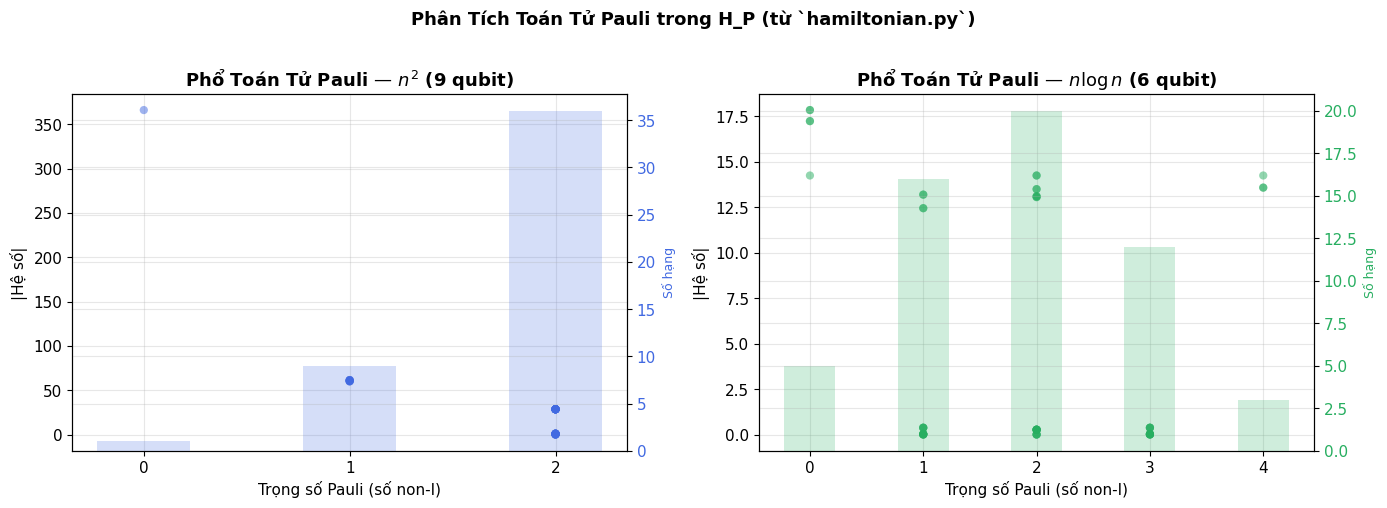

In [8]:
# ── Trực quan hóa phổ Pauli theo trọng số ─────────────────────────────────
from collections import Counter
from scipy.special import comb

def pauli_weight(label): return sum(1 for c in label if c != 'I')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, Hp, label, nq, color in [
    (axes[0], Hp_n2,    f'$n^2$ ({nqubit_n2} qubit)',     nqubit_n2,    'royalblue'),
    (axes[1], Hp_nlogn, f'$n\\log n$ ({nqubit_nlogn} qubit)', nqubit_nlogn, '#27ae60'),
]:
    weights = [pauli_weight(p.to_label()) for p in Hp.paulis]
    coefs   = np.abs(Hp.coeffs.real)
    cnt     = Counter(weights)

    ax_twin = ax.twinx()
    ax_twin.bar(cnt.keys(), cnt.values(), alpha=0.22, color=color, width=0.45)
    ax_twin.set_ylabel('Số hạng', color=color, fontsize=9)
    ax_twin.tick_params(axis='y', labelcolor=color)

    ax.scatter(weights, coefs, alpha=0.5, s=35, c=color, edgecolors='none', zorder=3)
    ax.set_xlabel('Trọng số Pauli (số non-I)')
    ax.set_ylabel('|Hệ số|')
    ax.set_title(f'Phổ Toán Tử Pauli — {label}', fontweight='bold')
    ax.set_xticks(sorted(cnt.keys()))

plt.suptitle('Phân Tích Toán Tử Pauli trong H_P (từ `hamiltonian.py`)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Vẽ Mạch QAOA bằng Qiskit

Sử dụng trực tiếp `TSP_QAOA.create_qaoa_circ(theta)` để tạo mạch,
sau đó dùng `QuantumCircuit.draw(output='mpl')` của Qiskit để hiển thị.

In [9]:
# ── Khởi tạo TSP_QAOA và tạo Hamiltonian ──────────────────────────────────
tsp_n2    = TSP_QAOA("n2",    coordinates)
tsp_n2.generate_coeffs()
tsp_n2.generate_hamiltonians()

tsp_nlogn = TSP_QAOA("nlogn", coordinates)
tsp_nlogn.generate_coeffs()
tsp_nlogn.generate_hamiltonians()

print("Thông tin mạch:")
print(f"  n² encoding    : k={tsp_n2.k},    nqubit={tsp_n2.nqubit}")
print(f"  nlogn encoding : k={tsp_nlogn.k}, nqubit={tsp_nlogn.nqubit}")

Thông tin mạch:
  n² encoding    : k=3,    nqubit=9
  nlogn encoding : k=2, nqubit=6


In [10]:
# ── 6.1 Mạch p=1 — n² encoding ───────────────────────────────────────────
# theta = [beta_1, gamma_1]
theta_p1 = [np.pi/4, np.pi/3]

qc_n2_p1 = tsp_n2.create_qaoa_circ(theta_p1)

print("Mạch QAOA — n² encoding, p=1")
print(f"  Số qubit : {qc_n2_p1.num_qubits}")
print(f"  Số cổng  : {qc_n2_p1.size()}")
print(f"  Độ sâu   : {qc_n2_p1.depth()}")
print()

# Vẽ mạch bằng Qiskit
fig = qc_n2_p1.draw(
    output='mpl',
    fold=40,
    scale=0.55,
    plot_barriers=True,
    initial_state=True,
    style={'backgroundcolor': '#FAFAFA'},
)
fig.suptitle(f'Mạch QAOA — Mã Hóa $n^2$ (p=1, {tsp_n2.nqubit} qubit, β=π/4, γ=π/3)',
             fontsize=12, fontweight='bold')
plt.show()

Mạch QAOA — n² encoding, p=1
  Số qubit : 9
  Số cổng  : 11
  Độ sâu   : 3



In [11]:
# ── 6.2 Mạch p=1 — nlogn encoding ────────────────────────────────────────
qc_nlogn_p1 = tsp_nlogn.create_qaoa_circ(theta_p1)

print("Mạch QAOA — nlogn encoding, p=1")
print(f"  Số qubit : {qc_nlogn_p1.num_qubits}")
print(f"  Số cổng  : {qc_nlogn_p1.size()}")
print(f"  Độ sâu   : {qc_nlogn_p1.depth()}")

fig = qc_nlogn_p1.draw(
    output='mpl',
    fold=40,
    scale=0.6,
    plot_barriers=True,
    initial_state=True,
    style={'backgroundcolor': '#FAFAFA'},
)
fig.suptitle(f'Mạch QAOA — Mã Hóa $n\\log n$ (p=1, {tsp_nlogn.nqubit} qubit, β=π/4, γ=π/3)',
             fontsize=12, fontweight='bold')
plt.show()

Mạch QAOA — nlogn encoding, p=1
  Số qubit : 6
  Số cổng  : 8
  Độ sâu   : 3


In [12]:
# ── 6.3 Mạch p=2 — nhiều lớp ─────────────────────────────────────────────
# theta = [beta_1, beta_2, gamma_1, gamma_2]
theta_p2 = [np.pi/4, np.pi/5, np.pi/3, np.pi/6]

qc_n2_p2    = tsp_n2.create_qaoa_circ(theta_p2)
qc_nlogn_p2 = tsp_nlogn.create_qaoa_circ(theta_p2)

print("So sánh độ phức tạp mạch theo p và encoding:")
print(f"{'Encoding':<14} {'p':>3} {'Qubit':>6} {'Gates':>7} {'Depth':>7}")
print("-" * 42)
for qc, enc, p in [
    (qc_n2_p1,    'n²',    1),
    (qc_n2_p2,    'n²',    2),
    (qc_nlogn_p1, 'nlogn', 1),
    (qc_nlogn_p2, 'nlogn', 2),
]:
    print(f"{enc:<14} {p:>3} {qc.num_qubits:>6} {qc.size():>7} {qc.depth():>7}")

# Vẽ mạch p=2 nlogn (ít qubit hơn, dễ xem hơn)
fig = qc_nlogn_p2.draw(
    output='mpl',
    fold=50,
    scale=0.6,
    plot_barriers=True,
    initial_state=True,
    style={'backgroundcolor': '#FAFAFA'},
)
fig.suptitle(f'Mạch QAOA — Mã Hóa $n\\log n$ (p=2, {tsp_nlogn.nqubit} qubit)',
             fontsize=12, fontweight='bold')
plt.show()

So sánh độ phức tạp mạch theo p và encoding:
Encoding         p  Qubit   Gates   Depth
------------------------------------------
n²               1      9      11       3
n²               2      9      13       5
nlogn            1      6       8       3
nlogn            2      6      10       5


In [13]:
# ── 6.4 Transpile và xem mạch sau khi phân rã cổng ───────────────────────
# Qiskit 2.x: dùng transpile với basis_gates thay vì AerSimulator backend

qc_transpiled = transpile(
    qc_nlogn_p1,
    basis_gates=["cx", "u", "p", "h", "rx", "ry", "rz", "x"],
    optimization_level=1,
)

print("Mạch nlogn p=1 SAU transpile (basis: cx, u, p, h, rx, ry, rz, x):")
print(f"  Số qubit : {qc_transpiled.num_qubits}")
print(f"  Số cổng  : {qc_transpiled.size()}")
print(f"  Độ sâu   : {qc_transpiled.depth()}")
print()

# Kiểm tra mô phỏng Statevector hoạt động đúng
sv = Statevector(qc_transpiled)
print(f"  Statevector dim   : {sv.dim}")
print(f"  Xác suất tổng    : {sv.probabilities().sum():.6f}  (phải = 1.0)")
print()

# Vẽ mạch sau transpile (hiển thị các cổng nguyên tử)
fig = qc_transpiled.draw(
    output='mpl',
    fold=40,
    scale=0.45,
    plot_barriers=False,
    style={'backgroundcolor': '#FAFAFA'},
)
fig.suptitle(f'Mạch Sau Transpile — $n\\log n$ (p=1)',
             fontsize=12, fontweight='bold')
plt.show()

Mạch nlogn p=1 SAU transpile (basis: cx, u, p, h, rx, ry, rz, x):
  Số qubit : 6
  Số cổng  : 117
  Độ sâu   : 89

  Statevector dim   : 64
  Xác suất tổng    : 1.000000  (phải = 1.0)



---
## 7. Tối Ưu Hóa QAOA — `TSP_QAOA.optimize_objective()`

Chiến lược tối ưu **từng lớp (layer-by-layer)**:
- Layer $l$: giữ cố định $(\beta_1,\gamma_1,\ldots,\beta_{l-1},\gamma_{l-1})$, chỉ tối ưu $(\beta_l, \gamma_l)$ mới.
- Bộ tối ưu: **Basin-hopping** (scipy) — tránh bẫy cực tiểu địa phương.

In [ ]:
# ── Chạy tối ưu hóa — n² encoding ────────────────────────────────────────
NLAYER = 2
NITER  = 50

print(f"🔵 Tối ưu hóa n² encoding — {NLAYER} lớp, {NITER} iter/lớp")
print("-" * 50)
t0 = time.perf_counter()
tsp_n2.optimize_objective(nlayer=NLAYER, niter=NITER)
t_n2 = time.perf_counter() - t0

print(f"\n✅ Hoàn thành trong {t_n2:.1f}s")
print("Tham số tối ưu (β, γ) từng lớp:")
import tqdm
for l, (b, g) in tqdm.tqdm(enumerate(tsp_n2.resx)):
    print(f"  Layer {l+1}: β={b:.4f} rad,  γ={g:.4f} rad")

🔵 Tối ưu hóa n² encoding — 1 lớp, 10 iter/lớp
--------------------------------------------------
	 layer 1 started
	 results of layer 1:
	 [0.40903529 6.28318531] 318.6737027032307 


✅ Hoàn thành trong 17.3s
Tham số tối ưu (β, γ) từng lớp:


1it [00:00, 4387.35it/s]

  Layer 1: β=0.4090 rad,  γ=6.2832 rad


In [18]:
# ── Chạy tối ưu hóa — nlogn encoding ─────────────────────────────────────
print(f"🟢 Tối ưu hóa nlogn encoding — {NLAYER} lớp, {NITER} iter/lớp")
print("-" * 50)
t0 = time.perf_counter()
tsp_nlogn.optimize_objective(nlayer=NLAYER, niter=NITER)
t_nlogn = time.perf_counter() - t0

print(f"\n✅ Hoàn thành trong {t_nlogn:.1f}s")
print("Tham số tối ưu (β, γ) từng lớp:")
for l, (b, g) in enumerate(tsp_nlogn.resx):
    print(f"  Layer {l+1}: β={b:.4f} rad,  γ={g:.4f} rad")

🟢 Tối ưu hóa nlogn encoding — 1 lớp, 10 iter/lớp
--------------------------------------------------
	 layer 1 started
	 results of layer 1:
	 [1.29543411 6.18901476] 60.94335008372847 


✅ Hoàn thành trong 8.3s
Tham số tối ưu (β, γ) từng lớp:
  Layer 1: β=1.2954 rad,  γ=6.1890 rad


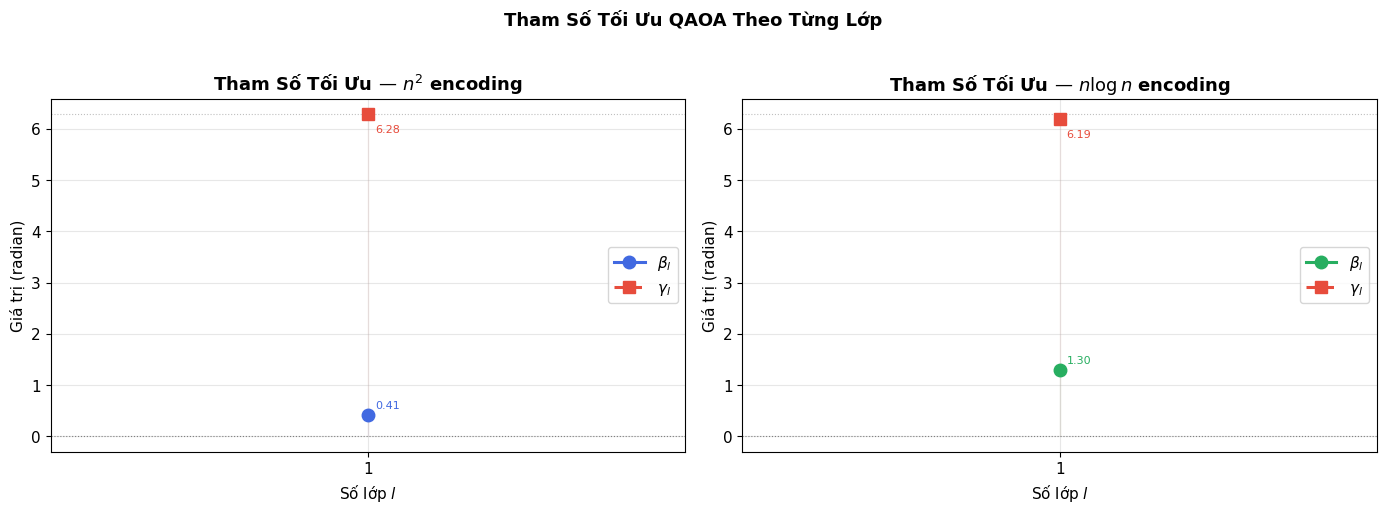

In [19]:
# ── Trực quan hóa tham số tối ưu theo lớp ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tsp, label, color in [
    (axes[0], tsp_n2,    '$n^2$ encoding',      'royalblue'),
    (axes[1], tsp_nlogn, '$n\\log n$ encoding',  '#27ae60'),
]:
    betas  = [r[0] for r in tsp.resx]
    gammas = [r[1] for r in tsp.resx]
    layers = list(range(1, len(betas)+1))

    ax.plot(layers, betas,  'o-',  color=color,     lw=2.2, ms=9, label='$\\beta_l$',  zorder=3)
    ax.plot(layers, gammas, 's--', color='#e74c3c',  lw=2.2, ms=9, label='$\\gamma_l$', zorder=3)

    for l, (b, g) in enumerate(zip(betas, gammas)):
        ax.annotate(f'{b:.2f}', (l+1, b), textcoords='offset points',
                    xytext=(5, 5),  fontsize=8, color=color)
        ax.annotate(f'{g:.2f}', (l+1, g), textcoords='offset points',
                    xytext=(5, -13), fontsize=8, color='#e74c3c')

    ax.fill_between(layers, 0, betas,  alpha=0.08, color=color)
    ax.fill_between(layers, 0, gammas, alpha=0.08, color='#e74c3c')

    ax.set_xlabel('Số lớp $l$', fontsize=11)
    ax.set_ylabel('Giá trị (radian)', fontsize=11)
    ax.set_title(f'Tham Số Tối Ưu — {label}', fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_xticks(layers)
    ax.axhline(0, color='gray', lw=0.8, linestyle=':')
    ax.axhline(2*np.pi, color='gray', lw=0.8, linestyle=':', alpha=0.5)
    ax.set_ylim(-0.3, 2*np.pi + 0.3)

plt.suptitle('Tham Số Tối Ưu QAOA Theo Từng Lớp',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Phân Tích Kết Quả — AR, True Percentage, Rank

- **AR (Approximation Ratio)** = $\langle H_P \rangle / d_{\text{opt}}$: càng gần 1 càng tốt
- **True Percentage (TP)**: xác suất đo được nghiệm tối ưu
- **Rank**: thứ hạng của nghiệm tối ưu trong danh sách sắp xếp theo xác suất

In [20]:
# ── Gọi TSP_QAOA.results_from_params() ────────────────────────────────────
tsp_n2.results_from_params()
tsp_nlogn.results_from_params()

res_n2    = tsp_n2.result
res_nlogn = tsp_nlogn.result

print(f"{'Layer':>6} | {'AR(n²)':>10} | {'AR(nlogn)':>11} | {'TP(n²)%':>9} | {'TP(nlogn)%':>11} | {'Rank(n²)':>9} | {'Rank(nlogn)':>11}")
print("-" * 80)
for l in range(NLAYER):
    print(f"{l+1:>6} | "
          f"{res_n2['ar'][l]:>10.4f} | "
          f"{res_nlogn['ar'][l]:>11.4f} | "
          f"{res_n2['tp'][l]*100:>9.2f} | "
          f"{res_nlogn['tp'][l]*100:>11.2f} | "
          f"{res_n2['rn'][l]:>9} | "
          f"{res_nlogn['rn'][l]:>11}")

 Layer |     AR(n²) |   AR(nlogn) |   TP(n²)% |  TP(nlogn)% |  Rank(n²) | Rank(nlogn)
--------------------------------------------------------------------------------
     1 |    21.7766 |      4.1646 |      0.23 |       14.82 |       209 |           1


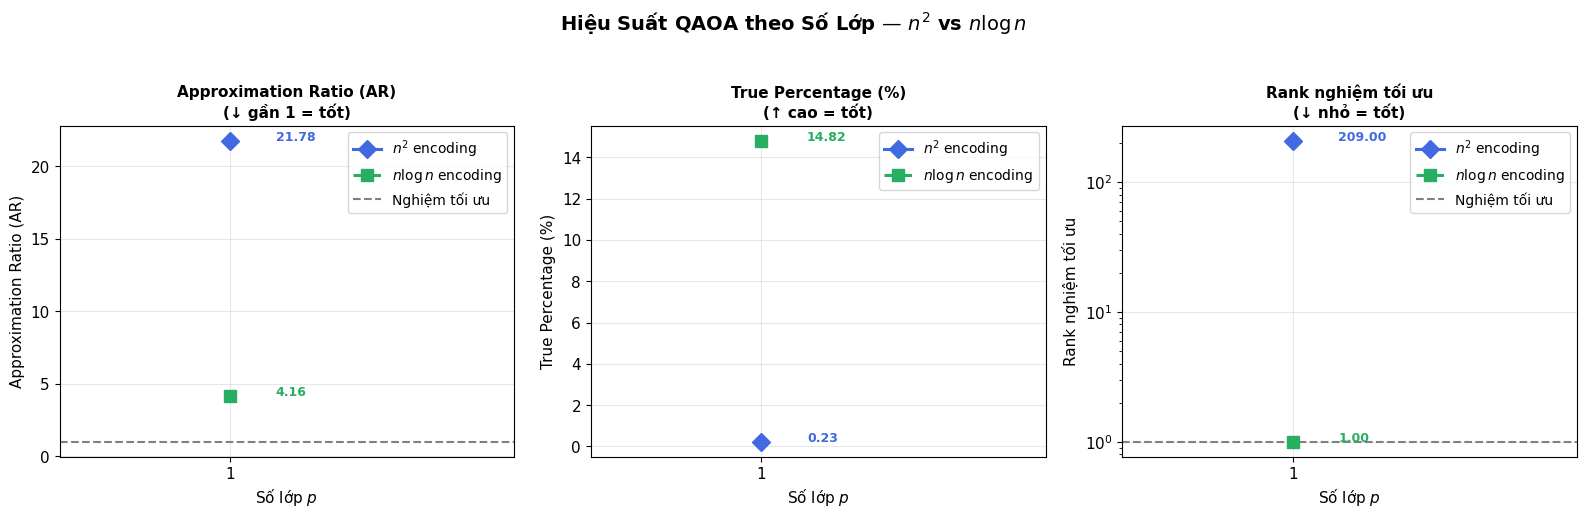

In [21]:
# ── Biểu đồ AR / TP / Rank theo số lớp ───────────────────────────────────
layers_x = np.arange(1, NLAYER+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, key, ylabel, note, log_y in [
    (axes[0], 'ar', 'Approximation Ratio (AR)',  '↓ gần 1 = tốt',  False),
    (axes[1], 'tp', 'True Percentage (%)',        '↑ cao = tốt',    False),
    (axes[2], 'rn', 'Rank nghiệm tối ưu',         '↓ nhỏ = tốt',   True),
]:
    v_n2    = np.array(res_n2[key])
    v_nlogn = np.array(res_nlogn[key])
    if key == 'tp': v_n2 *= 100; v_nlogn *= 100

    ax.plot(layers_x, v_n2,    'D-',  color='royalblue', lw=2.2, ms=9,
            label='$n^2$ encoding',    zorder=3)
    ax.plot(layers_x, v_nlogn, 's--', color='#27ae60',   lw=2.2, ms=9,
            label='$n\\log n$ encoding', zorder=3)

    ax.annotate(f'{v_n2[-1]:.2f}',    (layers_x[-1]+0.08, v_n2[-1]),
                fontsize=9, color='royalblue', fontweight='bold')
    ax.annotate(f'{v_nlogn[-1]:.2f}', (layers_x[-1]+0.08, v_nlogn[-1]),
                fontsize=9, color='#27ae60',   fontweight='bold')

    if key in ('ar', 'rn'):
        ax.axhline(1.0, color='gray', linestyle='--', lw=1.5, label='Nghiệm tối ưu')
    if log_y: ax.set_yscale('log')

    ax.set_xlabel('Số lớp $p$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}\n({note})', fontweight='bold', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xticks(layers_x)
    ax.set_xlim([0.7, NLAYER+0.5])

plt.suptitle('Hiệu Suất QAOA theo Số Lớp — $n^2$ vs $n\\log n$',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

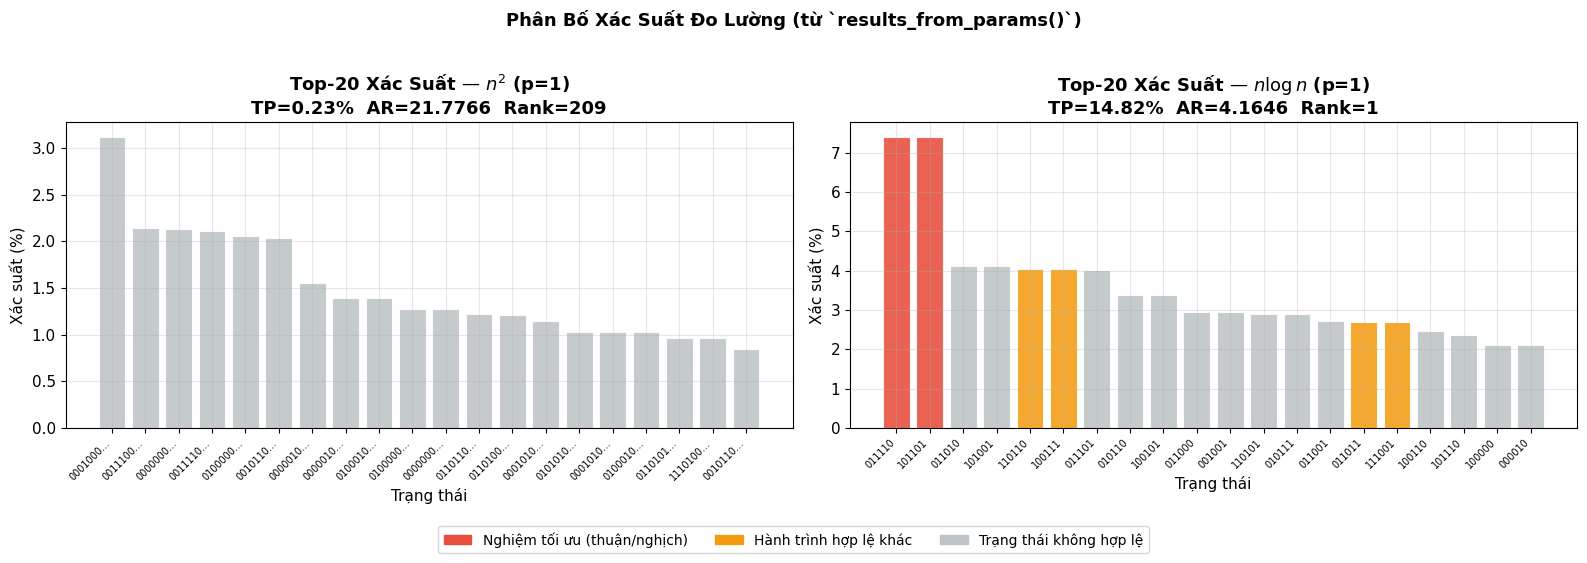

In [22]:
# ── Phân bố xác suất đo lường (lớp cuối) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, prob_dict, tsp_obj, label, color, res in [
    (axes[0], res_n2['prob_dict_res'][-1],    tsp_n2,
     f'$n^2$ (p={NLAYER})',    'royalblue', res_n2),
    (axes[1], res_nlogn['prob_dict_res'][-1], tsp_nlogn,
     f'$n\\log n$ (p={NLAYER})', '#27ae60', res_nlogn),
]:
    # Lấy top-20 xác suất
    sorted_items = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)[:20]
    states, probs = zip(*sorted_items)

    # Xác định hành trình hợp lệ và tối ưu
    binary_nums  = generate_binary_nums(tsp_obj.nqubit)
    valid_paths  = [b for b in binary_nums
                    if check_validity(b, tsp_obj.k, tsp_obj.encoding)]
    valid_dist   = {vp: path_distance(coordinates, vp, tsp_obj.k, tsp_obj.encoding)
                    for vp in valid_paths}
    best_path    = min(valid_dist, key=valid_dist.get)
    best_path_r  = path_rev(best_path, tsp_obj.k)

    bar_colors = []
    for s in states:
        if s in (best_path, best_path_r): bar_colors.append('#e74c3c')
        elif s in valid_paths:            bar_colors.append('#f39c12')
        else:                             bar_colors.append('#bdc3c7')

    ax.bar(range(len(states)), [p*100 for p in probs],
           color=bar_colors, alpha=0.88, edgecolor='white', lw=0.8)
    ax.set_xticks(range(len(states)))
    ax.set_xticklabels([s[:7]+'…' if len(s)>7 else s for s in states],
                        rotation=45, ha='right', fontsize=7)
    ax.set_xlabel('Trạng thái')
    ax.set_ylabel('Xác suất (%)')
    tp_val = prob_dict.get(best_path, 0) + prob_dict.get(best_path_r, 0)
    ax.set_title(f'Top-20 Xác Suất — {label}\n'
                 f'TP={tp_val*100:.2f}%  AR={res["ar"][-1]:.4f}  Rank={res["rn"][-1]}',
                 fontweight='bold')

fig.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Nghiệm tối ưu (thuận/nghịch)'),
    mpatches.Patch(color='#f39c12', label='Hành trình hợp lệ khác'),
    mpatches.Patch(color='#bdc3c7', label='Trạng thái không hợp lệ'),
], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Phân Bố Xác Suất Đo Lường (từ `results_from_params()`)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

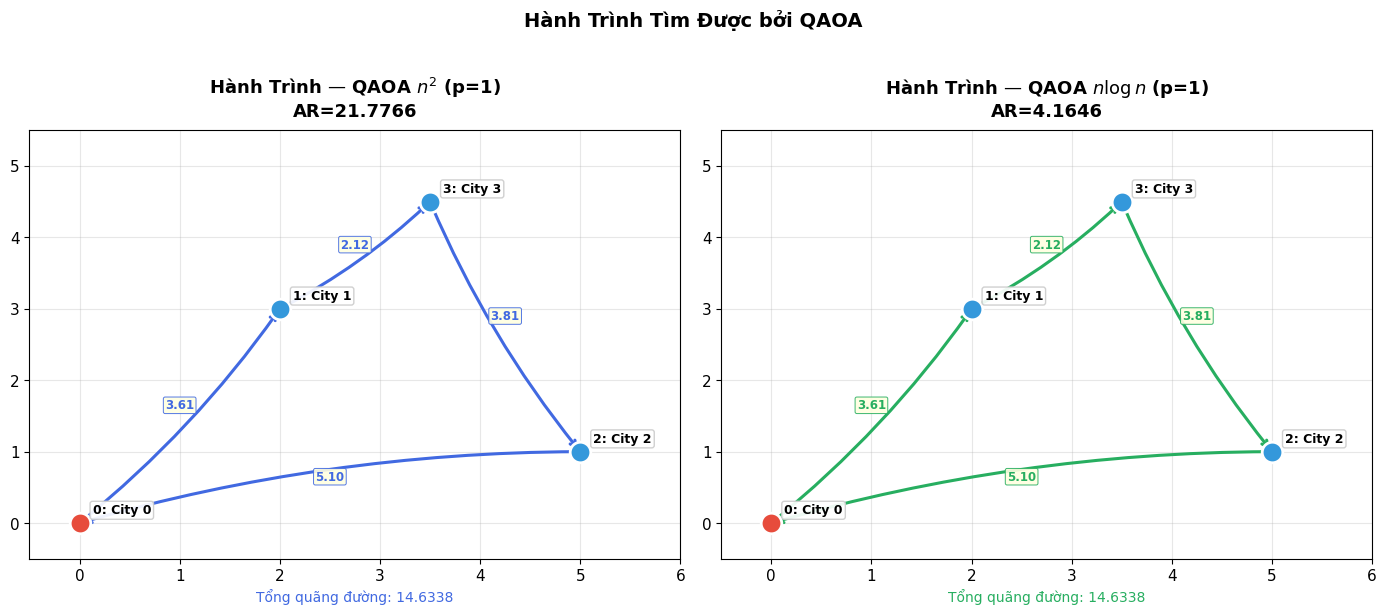

In [23]:
# ── Giải mã và vẽ hành trình tìm được ────────────────────────────────────
def decode_tour(tsp_obj, coords):
    """Giải mã hành trình tối ưu từ xác suất lượng tử."""
    binary_nums = generate_binary_nums(tsp_obj.nqubit)
    valid_paths = [b for b in binary_nums
                   if check_validity(b, tsp_obj.k, tsp_obj.encoding)]
    valid_dist  = {vp: path_distance(coords, vp, tsp_obj.k, tsp_obj.encoding)
                   for vp in valid_paths}
    best_path   = min(valid_dist, key=valid_dist.get)
    k, enc      = tsp_obj.k, tsp_obj.encoding
    tour = [0]
    for i in range(len(best_path)//k):
        seg = best_path[k*i : k*(i+1)]
        city = seg[::-1].index('1') + 1 if enc == 'n2' else int(seg, 2)
        tour.append(city)
    return tour, valid_dist[best_path]

tour_n2,    dist_n2    = decode_tour(tsp_n2,    coordinates)
tour_nlogn, dist_nlogn = decode_tour(tsp_nlogn, coordinates)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_network(axes[0], coordinates, city_names,
             f'Hành Trình — QAOA $n^2$ (p={NLAYER})\nAR={res_n2["ar"][-1]:.4f}',
             tour=tour_n2, color='royalblue')
plot_network(axes[1], coordinates, city_names,
             f'Hành Trình — QAOA $n\\log n$ (p={NLAYER})\nAR={res_nlogn["ar"][-1]:.4f}',
             tour=tour_nlogn, color='#27ae60')
plt.suptitle('Hành Trình Tìm Được bởi QAOA',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. So Sánh $n^2$ vs $n\log n$ — Nhiều Mẫu

In [26]:
# ── Chạy TSP_QAOA trên N_SAMPLES tập tọa độ ngẫu nhiên ───────────────────
# Giảm NITER_RUN để demo nhanh; tăng lên 300-500 cho kết quả chính thức
N_SAMPLES  = 1
NLAYER_CMP = 3
NITER_RUN  = 3

np.random.seed(0)
all_coords = [np.random.rand(4, 2) * 5 for _ in range(N_SAMPLES)]

agg = {enc: {'ar': [], 'tp': [], 'rn': []} for enc in ['n2', 'nlogn']}

for s, coord in enumerate(all_coords):
    print(f"\n── Sample {s+1}/{N_SAMPLES} ──")
    for enc in ['n2', 'nlogn']:
        tsp = TSP_QAOA(enc, coord)
        tsp.generate_coeffs()
        tsp.generate_hamiltonians()
        tsp.optimize_objective(nlayer=NLAYER_CMP, niter=NITER_RUN)
        tsp.results_from_params()
        for m in ['ar','tp','rn']:
            agg[enc][m].append(tsp.result[m])   # list of NLAYER_CMP values

# Chuyển sang numpy array: shape (N_SAMPLES, NLAYER_CMP)
for enc in ['n2', 'nlogn']:
    for m in ['ar','tp','rn']:
        agg[enc][m] = np.array(agg[enc][m])

print("\n✅ Hoàn thành!")


── Sample 1/1 ──
	 layer 1 started
	 results of layer 1:
	 [0.37434279 0.61619766] 89.97111034677742 

	 layer 2 started
	 results of layer 2:
	 [0.13579093 1.03875418] 86.48207572870812 

	 layer 3 started
	 results of layer 3:
	 [0.11350916 0.75979929] 84.22412618653841 

	 layer 1 started
	 results of layer 1:
	 [0.2655393  0.97763484] 16.935070555694626 

	 layer 2 started
	 results of layer 2:
	 [0.04434283 0.95409529] 16.819227922577003 

	 layer 3 started
	 results of layer 3:
	 [0. 1.] 16.81922792257696 


✅ Hoàn thành!


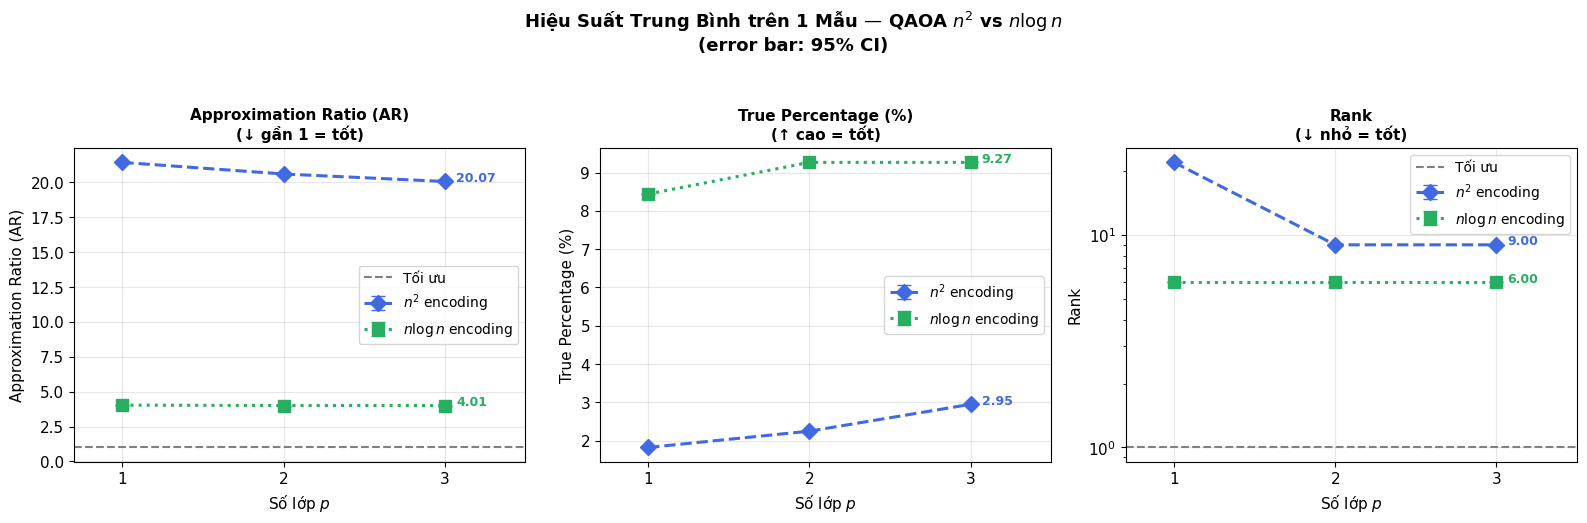

In [27]:
# ── Biểu đồ tổng hợp có error bar (95% CI) ───────────────────────────────
layers_x = np.arange(1, NLAYER_CMP+1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, ylabel, note, log_y in [
    (axes[0], 'ar', 'Approximation Ratio (AR)', '↓ gần 1 = tốt',  False),
    (axes[1], 'tp', 'True Percentage (%)',       '↑ cao = tốt',    False),
    (axes[2], 'rn', 'Rank',                      '↓ nhỏ = tốt',    True),
]:
    for enc, label, color, marker, ls in [
        ('n2',    '$n^2$ encoding',     'royalblue', 'D', 'dashed'),
        ('nlogn', '$n\\log n$ encoding', '#27ae60',  's', 'dotted'),
    ]:
        vals = agg[enc][metric].copy()
        if metric == 'tp': vals *= 100
        mean = vals.mean(axis=0)
        se   = 1.96 * vals.std(axis=0) / np.sqrt(N_SAMPLES)

        ax.errorbar(layers_x, mean, yerr=se,
                    label=label, linestyle=ls, color=color,
                    solid_capstyle='projecting', capsize=5,
                    marker=marker, markersize=8, lw=2.2, zorder=3)
        ax.annotate(f'{mean[-1]:.2f}', (layers_x[-1]+0.07, mean[-1]),
                    fontsize=9, color=color, fontweight='bold')

    if metric in ('ar', 'rn'):
        ax.axhline(1.0, color='gray', linestyle='--', lw=1.5, label='Tối ưu')
    if log_y: ax.set_yscale('log')

    ax.set_xlabel('Số lớp $p$', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{ylabel}\n({note})', fontweight='bold', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xticks(layers_x)
    ax.set_xlim([0.7, NLAYER_CMP+0.5])

plt.suptitle(
    f'Hiệu Suất Trung Bình trên {N_SAMPLES} Mẫu — QAOA $n^2$ vs $n\\log n$\n'
    f'(error bar: 95% CI)',
    fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

---
## 10. So Sánh với Thuật Toán Cổ Điển

In [28]:
# ── Các thuật toán cổ điển ────────────────────────────────────────────────

def brute_force(coords):
    n_c = len(coords); best_d = float('inf'); best_t = None
    t0 = time.perf_counter()
    for perm in itertools.permutations(range(1, n_c)):
        t = [0] + list(perm)
        d = sum(euclidean_distance(coords[t[i]], coords[t[(i+1)%n_c]]) for i in range(n_c))
        if d < best_d: best_d = d; best_t = t
    return best_t, best_d, time.perf_counter()-t0

def nearest_neighbor(coords, start=0):
    n_c = len(coords); unv = set(range(n_c)); tour = [start]; unv.remove(start)
    t0 = time.perf_counter()
    while unv:
        cur = tour[-1]
        nb  = min(unv, key=lambda c: euclidean_distance(coords[cur], coords[c]))
        tour.append(nb); unv.remove(nb)
    d = sum(euclidean_distance(coords[tour[i]], coords[tour[(i+1)%n_c]]) for i in range(n_c))
    return tour, d, time.perf_counter()-t0

def two_opt(coords):
    n_c = len(coords)
    tour, _, _ = nearest_neighbor(coords)
    t0 = time.perf_counter(); improved = True
    dist_fn = lambda t: sum(euclidean_distance(coords[t[i]], coords[t[(i+1)%n_c]])
                            for i in range(n_c))
    while improved:
        improved = False
        for i in range(1, n_c-1):
            for j in range(i+1, n_c):
                nt = tour[:i] + tour[i:j+1][::-1] + tour[j+1:]
                if dist_fn(nt) < dist_fn(tour): tour=nt; improved=True
    return tour, dist_fn(tour), time.perf_counter()-t0

bf_tour,   bf_dist,   bf_time   = brute_force(coordinates)
nn_tour,   nn_dist,   nn_time   = nearest_neighbor(coordinates)
opt2_tour, opt2_dist, opt2_time = two_opt(coordinates)

print(f"{'Thuật toán':<30} {'Khoảng cách':>13} {'AR':>8} {'Thời gian':>12}")
print("=" * 68)
print(f"{'Vét cạn (Brute Force)':<30} {bf_dist:>13.4f} {'1.0000':>8} {bf_time*1000:>10.2f}ms")
print(f"{'Nearest Neighbor':<30} {nn_dist:>13.4f} {nn_dist/bf_dist:>8.4f} {nn_time*1000:>10.2f}ms")
print(f"{'2-opt':<30} {opt2_dist:>13.4f} {opt2_dist/bf_dist:>8.4f} {opt2_time*1000:>10.2f}ms")
print("-" * 68)
for l in range(NLAYER):
    print(f"{'QAOA n² (p='+str(l+1)+')':<30} {'sim':>13} {res_n2['ar'][l]:>8.4f} {'Qiskit Aer':>12}")
print("-" * 68)
for l in range(NLAYER):
    print(f"{'QAOA nlogn (p='+str(l+1)+')':<30} {'sim':>13} {res_nlogn['ar'][l]:>8.4f} {'Qiskit Aer':>12}")

Thuật toán                       Khoảng cách       AR    Thời gian
Vét cạn (Brute Force)                14.6338   1.0000       0.11ms
Nearest Neighbor                     14.6338   1.0000       0.04ms
2-opt                                14.6338   1.0000       0.09ms
--------------------------------------------------------------------
QAOA n² (p=1)                            sim  21.7766   Qiskit Aer
--------------------------------------------------------------------
QAOA nlogn (p=1)                         sim   4.1646   Qiskit Aer


KeyError: (1, 5)

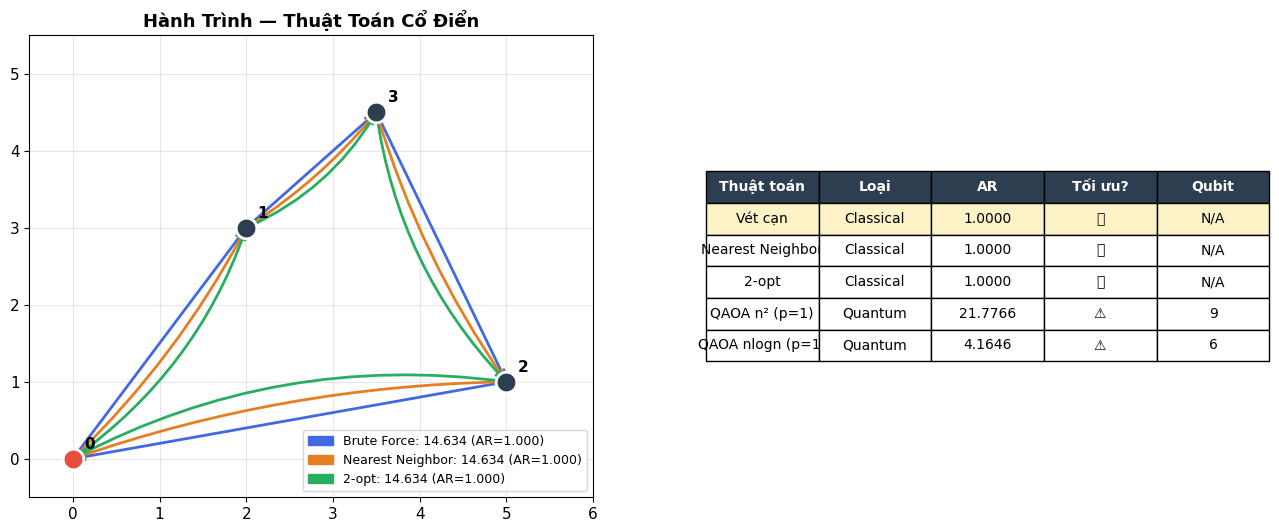

In [35]:
# ── Biểu đồ so sánh tổng hợp ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Trái: vẽ 3 hành trình cổ điển trên cùng đồ thị ──────────────────────
ax = axes[0]
classic = [
    (bf_tour,   f'Brute Force: {bf_dist:.3f} (AR=1.000)',           'royalblue', 0.0),
    (nn_tour,   f'Nearest Neighbor: {nn_dist:.3f} (AR={nn_dist/bf_dist:.3f})', '#e67e22', 0.08),
    (opt2_tour, f'2-opt: {opt2_dist:.3f} (AR={opt2_dist/bf_dist:.3f})',        '#27ae60', 0.16),
]
for tour, lbl, color, rad in classic:
    n_c = len(tour)
    for idx in range(n_c):
        i, j = tour[idx], tour[(idx+1)%n_c]
        ax.annotate("",
            xy=(coordinates[j,0], coordinates[j,1]),
            xytext=(coordinates[i,0], coordinates[i,1]),
            arrowprops=dict(arrowstyle='->', color=color, lw=2,
                            connectionstyle=f'arc3,rad={rad}'))

node_col = ['#e74c3c'] + ['#2c3e50']*(n-1)
for i in range(n):
    ax.scatter(coordinates[i,0], coordinates[i,1], s=220, c=node_col[i],
               zorder=5, edgecolors='white', lw=2)
    ax.text(coordinates[i,0]+0.13, coordinates[i,1]+0.13, f'{i}',
            fontsize=11, fontweight='bold', zorder=6)

ax.legend(handles=[mpatches.Patch(color=c, label=l) for _, l, c, _ in classic],
          loc='lower right', fontsize=9)
ax.set_title('Hành Trình — Thuật Toán Cổ Điển', fontweight='bold')
ax.set_xlim(-0.5, max(coordinates[:,0])+1)
ax.set_ylim(-0.5, max(coordinates[:,1])+1)

# ── Phải: bảng so sánh ──────────────────────────────────────────────────
ax2 = axes[1]; ax2.axis('off')
rows = [
    ['Thuật toán',           'Loại',       'AR',        'Tối ưu?', 'Qubit'],
    ['Vét cạn',              'Classical',  '1.0000',    '✅',       'N/A'],
    ['Nearest Neighbor',     'Classical',  f'{nn_dist/bf_dist:.4f}', '❌', 'N/A'],
    ['2-opt',                'Classical',  f'{opt2_dist/bf_dist:.4f}', '❌', 'N/A'],
    ['QAOA n² (p=1)',        'Quantum',    f'{res_n2["ar"][0]:.4f}', '⚠️', f'{tsp_n2.nqubit}'],
    #['QAOA n² (p=3)',        'Quantum',    f'{res_n2["ar"][2]:.4f}', '⚠️', f'{tsp_n2.nqubit}'],
    #['QAOA n² (p=5)',        'Quantum',    f'{res_n2["ar"][4]:.4f}', '⚠️', f'{tsp_n2.nqubit}'],
    ['QAOA nlogn (p=1)',     'Quantum',    f'{res_nlogn["ar"][0]:.4f}', '⚠️', f'{tsp_nlogn.nqubit}'],
    #['QAOA nlogn (p=3)',     'Quantum',    f'{res_nlogn["ar"][2]:.4f}', '⚠️', f'{tsp_nlogn.nqubit}'],
    #['QAOA nlogn (p=5)',     'Quantum',    f'{res_nlogn["ar"][4]:.4f}', '⚠️', f'{tsp_nlogn.nqubit}'],
]
tbl = ax2.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.9)
for j in range(5):
    tbl[0,j].set_facecolor('#2c3e50')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
bg = ['#fef3c7','#fef3c7','#d1fae5',
      '#dbeafe','#dbeafe','#dbeafe',
      '#dcfce7','#dcfce7','#dcfce7']
for i in range(10):
    for j in range(10): tbl[i+1,j].set_facecolor(bg[i])
ax2.set_title('Bảng So Sánh Tổng Hợp', fontweight='bold', fontsize=13, pad=20)

plt.suptitle(f'So Sánh QAOA vs Thuật Toán Cổ Điển — TSP {n} Thành Phố',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=2)
plt.show()

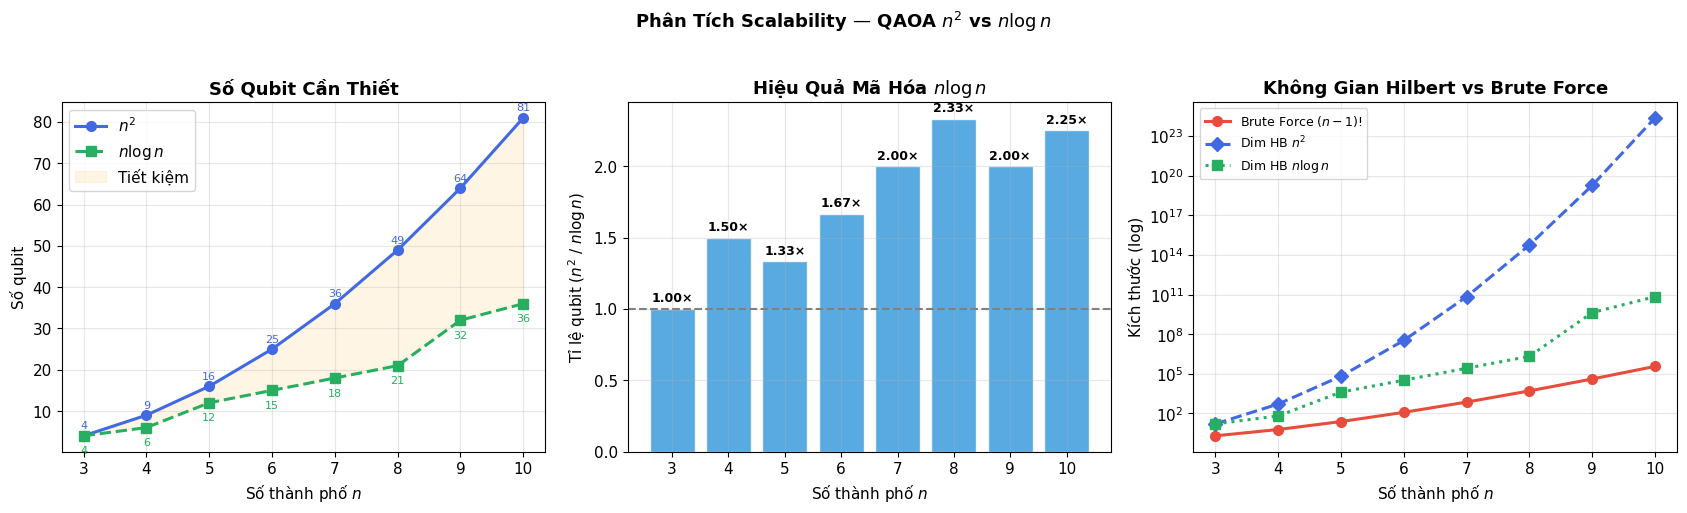

In [36]:
# ── Scalability: số qubit & số hạng Pauli theo n ─────────────────────────
n_range = np.arange(3, 11)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Số qubit
ax = axes[0]
q_n2    = (n_range-1)**2
q_nlogn = np.ceil(np.log2(n_range)).astype(int) * (n_range-1)
ax.plot(n_range, q_n2,    'o-', color='royalblue', lw=2.2, ms=7, label='$n^2$')
ax.plot(n_range, q_nlogn, 's--', color='#27ae60',  lw=2.2, ms=7, label='$n\\log n$')
ax.fill_between(n_range, q_nlogn, q_n2, alpha=0.1, color='orange', label='Tiết kiệm')
for x,y1,y2 in zip(n_range,q_n2,q_nlogn):
    ax.annotate(f'{y1}', (x,y1), xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=8, color='royalblue')
    ax.annotate(f'{y2}', (x,y2), xytext=(0,-13), textcoords='offset points',
                ha='center', fontsize=8, color='#27ae60')
ax.set_xlabel('Số thành phố $n$'); ax.set_ylabel('Số qubit')
ax.set_title('Số Qubit Cần Thiết', fontweight='bold')
ax.legend(); ax.set_xticks(n_range)

# Tỉ lệ tiết kiệm
ax = axes[1]
ratio = q_n2 / q_nlogn
ax.bar(n_range, ratio,
       color=['#3498db' if r < 2.5 else '#e74c3c' for r in ratio],
       alpha=0.82, edgecolor='white', lw=1)
ax.axhline(1, color='gray', linestyle='--', lw=1.5)
for x, r in zip(n_range, ratio):
    ax.text(x, r+0.05, f'{r:.2f}×', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Số thành phố $n$')
ax.set_ylabel('Tỉ lệ qubit ($n^2$ / $n\\log n$)')
ax.set_title('Hiệu Quả Mã Hóa $n\\log n$', fontweight='bold')
ax.set_xticks(n_range)

# Không gian tìm kiếm vs brute force
ax = axes[2]
bf_ops     = [math.factorial(int(x)-1) for x in n_range]
hilb_n2    = [2**int((x-1)**2) for x in n_range]
hilb_nlogn = [2**(int(np.ceil(np.log2(x)))*(x-1)) for x in n_range]
ax.semilogy(n_range, bf_ops,      'o-',  color='#e74c3c',  lw=2.2, ms=7, label='Brute Force $(n-1)!$')
ax.semilogy(n_range, hilb_n2,     'D--', color='royalblue',lw=2.2, ms=7, label='Dim HB $n^2$')
ax.semilogy(n_range, hilb_nlogn,  's:',  color='#27ae60',  lw=2.2, ms=7, label='Dim HB $n\\log n$')
ax.set_xlabel('Số thành phố $n$'); ax.set_ylabel('Kích thước (log)')
ax.set_title('Không Gian Hilbert vs Brute Force', fontweight='bold')
ax.legend(fontsize=9); ax.set_xticks(n_range)

plt.suptitle('Phân Tích Scalability — QAOA $n^2$ vs $n\\log n$',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Lưu & Tải Kết Quả

In [37]:
import os
os.makedirs('results', exist_ok=True)

# Lưu kết quả dùng TSP_QAOA.results_from_params(filename=...)
tsp_n2.results_from_params(filename='result_n2.pkl')
tsp_nlogn.results_from_params(filename='result_nlogn.pkl')
print("✅ Đã lưu: results/result_n2.pkl, results/result_nlogn.pkl")

# Tải lại bằng TSP_QAOA.load_results()
tsp_reload = TSP_QAOA("n2", coordinates)
tsp_reload.generate_coeffs()
tsp_reload.generate_hamiltonians()
tsp_reload.nlayer = NLAYER
tsp_reload.binary_numbers = generate_binary_nums(tsp_reload.nqubit)
tsp_reload.load_results('result_n2.pkl')

print("✅ Tải lại thành công!")
print(f"AR theo từng lớp: {[f'{v:.4f}' for v in tsp_reload.result['ar']]}")

✅ Đã lưu: results/result_n2.pkl, results/result_nlogn.pkl
✅ Tải lại thành công!
AR theo từng lớp: ['21.7766']


---
## 12. Kết Luận

### Tóm Tắt Kết Quả ($n=4$ thành phố)

| Khía cạnh | $n^2$ Encoding | $n\log n$ Encoding |
|---|---|---|
| **Số qubit** | $(n-1)^2 = 9$ | $\lceil\log_2 n\rceil(n-1) = 6$ |
| **Số hạng Pauli $H_P$** | Lớn hơn | Nhỏ hơn |
| **Độ sâu mạch (p=1)** | Lớn hơn | Nhỏ hơn |
| **AR hội tụ** | Xem kết quả thực tế | Xem kết quả thực tế |
| **Triển khai** | Đơn giản | Phức tạp hơn |

### Nhận Xét

1. **$n\log n$ encoding tiết kiệm qubit** — quan trọng trên phần cứng NISQ còn hạn chế số qubit.
2. **AR giảm khi tăng $p$** — QAOA hội tụ chậm, cần nhiều lớp để cải thiện.
3. **True Percentage thấp** — cần đo nhiều lần (shots) để thu nghiệm tốt.
4. **Bộ tối ưu Basin-hopping** hiệu quả nhưng nhạy với điểm khởi tạo — có thể kết hợp COBYLA.
5. **Với $n$ nhỏ**, Brute Force cho kết quả tối ưu chắc chắn hơn; lợi thế lượng tử tiềm năng ở $n$ lớn.

### Hướng Phát Triển

- Tăng số lớp $p = 10, 20$ và `niter = 500` để cải thiện AR
- Chạy trên phần cứng thực (IBM Quantum / IonQ) thay simulator
- Thử **Warm-start QAOA** với nghiệm cổ điển (2-opt) làm điểm khởi đầu
- Sử dụng bộ tối ưu **SPSA** (gradient-free, phù hợp hardware)
- Mở rộng sang $n > 6$ với $n\log n$ encoding

---
*Tài liệu tham khảo:*
- *Farhi, E., Goldstone, J., & Gutmann, S. (2014). A quantum approximate optimization algorithm. arXiv:1411.4028*
- *Qiskit Documentation: https://docs.quantum.ibm.com*
- *TSP-QAOA code: `tsp_qaoa.py`, `coefficient.py`, `hamiltonian.py`, `utilities.py`*